# 泛科學 YouTube Shorts 分析

統計學一（下）期末專題：以迴歸分析探討泛科學近兩週 Shorts 的觀看數驅動因子。

## 1. 載入資料

讀取最新一份 `channel_videos_*.csv`，並把 `published_at` 轉為 UTC datetime。若資料尚未抓取則中止並提示指令。

In [15]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from matplotlib import font_manager

from src import storage

In [16]:
# Mac 中文字型 fallback：找得到哪個就用哪個
_available = {f.name for f in font_manager.fontManager.ttflist}
for _candidate in ["PingFang TC", "Heiti TC", "Apple LiGothic", "Arial Unicode MS"]:
    if _candidate in _available:
        plt.rcParams["font.family"] = _candidate
        break
plt.rcParams["axes.unicode_minus"] = False
sns.set_style("whitegrid")

In [17]:
csv_path = storage.latest("channel_videos")
if csv_path is None:
    print("找不到 data/processed/channel_videos_*.csv")
    print("請先跑 `python main.py channel-compare --preset pansci_shorts` 抓資料")
    raise SystemExit("missing input data")

videos = pd.read_csv(csv_path)
videos["published_at"] = pd.to_datetime(videos["published_at"], utc=True)
videos["fetched_at"] = pd.to_datetime(videos["fetched_at"], utc=True, errors="coerce")

print(f"來源：{csv_path}")
print(f"shape: {videos.shape}")
print(f"日期區間：{videos['published_at'].min()} ~ {videos['published_at'].max()}")
if not videos.empty:
    print(f"頻道：{videos['channel_title'].iloc[0]}（{videos['channel_id'].iloc[0]}）")

來源：/Users/waynliu/Documents/NTU/台大/大二下/統計一下/final project/data/processed/channel_videos_20260510-143336.csv
shape: (200, 19)
日期區間：2025-12-05 12:02:10+00:00 ~ 2026-05-10 11:11:24+00:00
頻道：PanSci 泛科學（UCuHHKbwC0TWjeqxbqdO-N_g）


## 2. 篩出近兩週的 Shorts

以 2026-04-26 UTC 為近兩週起點。Shorts 標準寬鬆地分為兩種：≤60 秒（傳統定義）與 ≤180 秒（新版上限），同時計算以利後續比較。

In [ ]:
CUTOFF = pd.Timestamp("2026-04-26", tz="UTC")

recent = videos[videos["published_at"] >= CUTOFF].copy()
shorts_60 = recent[recent["duration_sec"] <= 60].copy()
shorts_180 = recent[recent["duration_sec"] <= 180].copy()
regular = recent[recent["duration_sec"] > 180].copy()

print(f"全部影片數：{len(videos)}")
print(f"近兩週影片數（>= {CUTOFF.date()}）：{len(recent)}")
print(f"  Shorts ≤60s：{len(shorts_60)}")
print(f"  Shorts ≤180s：{len(shorts_180)}")
print(f"  一般影片 (>180s)：{len(regular)}")

# 主分析以 ≤180s 為準
shorts = shorts_180

全部影片數：200
近兩週影片數（>= 2026-04-26）：20
  Shorts ≤60s：0
  Shorts ≤180s：15
  一般影片 (>180s)：5


## 3. 敘述統計

對 Shorts 子集合的時長與三項互動指標做基本敘述統計。

In [19]:
metrics_cols = ["duration_sec", "view_count", "like_count", "comment_count"]
if len(shorts) == 0:
    print("近兩週沒有 Shorts，無法產生敘述統計")
else:
    desc = shorts[metrics_cols].describe().T[["mean", "50%", "std", "min", "max"]]
    desc = desc.rename(columns={"50%": "median"})
    print(desc.round(2).to_string())

                    mean   median        std      min       max
duration_sec      160.67    164.0      20.46     93.0     180.0
view_count     120709.07  86704.0  109586.39  31031.0  397393.0
like_count       3742.07   3234.0    2328.70   1490.0    9819.0
comment_count     161.73    129.0     119.56     36.0     484.0


## 4. EDA 視覺化

包含時長分布、觀看數分布（log）、每日上片數時序，以及觀看數對按讚／留言的散布圖（皆 log-log）。

/var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/ipykernel_28059/3757597594.py:9: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/ipykernel_28059/3757597594.py:9: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/ipykernel_28059/3757597594.py:9: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/ipykernel_28059/3757597594.py:9: UserWarning: Glyph 38263 (\N{CJK UNIFIED IDEOGRAPH-9577}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/ipykernel_28059/3757597594.py:9: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/ipyker

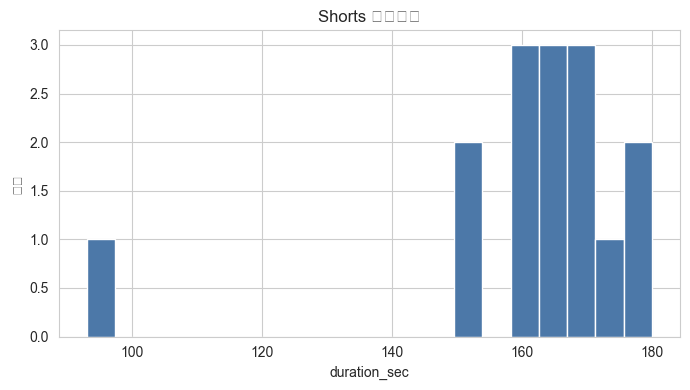

In [20]:
if len(shorts) == 0:
    print("近兩週沒有 Shorts，跳過視覺化")
else:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(shorts["duration_sec"], bins=20, color="#4C78A8", edgecolor="white")
    ax.set_title("Shorts 時長分布")
    ax.set_xlabel("duration_sec")
    ax.set_ylabel("次數")
    plt.tight_layout()
    plt.show()

/var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/ipykernel_28059/1977347307.py:13: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/ipykernel_28059/1977347307.py:13: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/ipykernel_28059/1977347307.py:13: UserWarning: Glyph 35264 (\N{CJK UNIFIED IDEOGRAPH-89C0}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/ipykernel_28059/1977347307.py:13: UserWarning: Glyph 30475 (\N{CJK UNIFIED IDEOGRAPH-770B}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/ipykernel_28059/1977347307.py:13: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/i

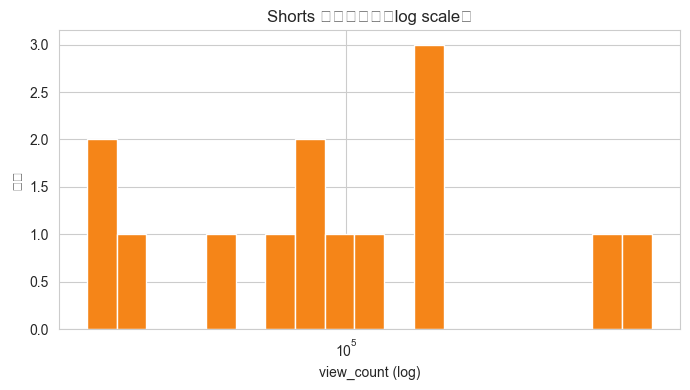

In [21]:
if len(shorts) == 0:
    print("略過")
else:
    # log scale 上的觀看數分布；+1 避免 log(0)
    fig, ax = plt.subplots(figsize=(7, 4))
    views_pos = shorts["view_count"].clip(lower=1)
    ax.hist(views_pos, bins=np.logspace(np.log10(views_pos.min()), np.log10(views_pos.max() + 1), 20),
            color="#F58518", edgecolor="white")
    ax.set_xscale("log")
    ax.set_title("Shorts 觀看數分布（log scale）")
    ax.set_xlabel("view_count (log)")
    ax.set_ylabel("次數")
    plt.tight_layout()
    plt.show()

/var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/ipykernel_28059/2387300156.py:12: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/ipykernel_28059/2387300156.py:12: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/ipykernel_28059/2387300156.py:12: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/ipykernel_28059/2387300156.py:12: UserWarning: Glyph 29255 (\N{CJK UNIFIED IDEOGRAPH-7247}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/ipykernel_28059/2387300156.py:12: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/i

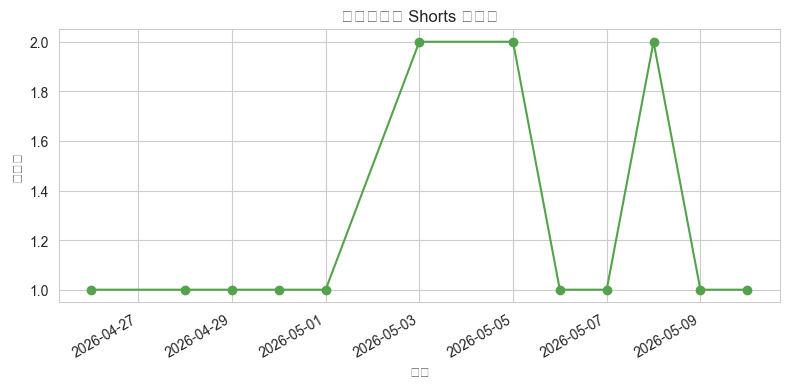

In [22]:
if len(shorts) == 0:
    print("略過")
else:
    daily = shorts.assign(date=shorts["published_at"].dt.tz_convert("UTC").dt.date) \
                  .groupby("date").size().rename("count")
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(daily.index, daily.values, marker="o", color="#54A24B")
    ax.set_title("近兩週每日 Shorts 上片數")
    ax.set_xlabel("日期")
    ax.set_ylabel("上片數")
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

/var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/ipykernel_28059/1271260513.py:16: UserWarning: Glyph 35264 (\N{CJK UNIFIED IDEOGRAPH-89C0}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/ipykernel_28059/1271260513.py:16: UserWarning: Glyph 30475 (\N{CJK UNIFIED IDEOGRAPH-770B}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/ipykernel_28059/1271260513.py:16: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/ipykernel_28059/1271260513.py:16: UserWarning: Glyph 25353 (\N{CJK UNIFIED IDEOGRAPH-6309}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/ipykernel_28059/1271260513.py:16: UserWarning: Glyph 35738 (\N{CJK UNIFIED IDEOGRAPH-8B9A}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/i

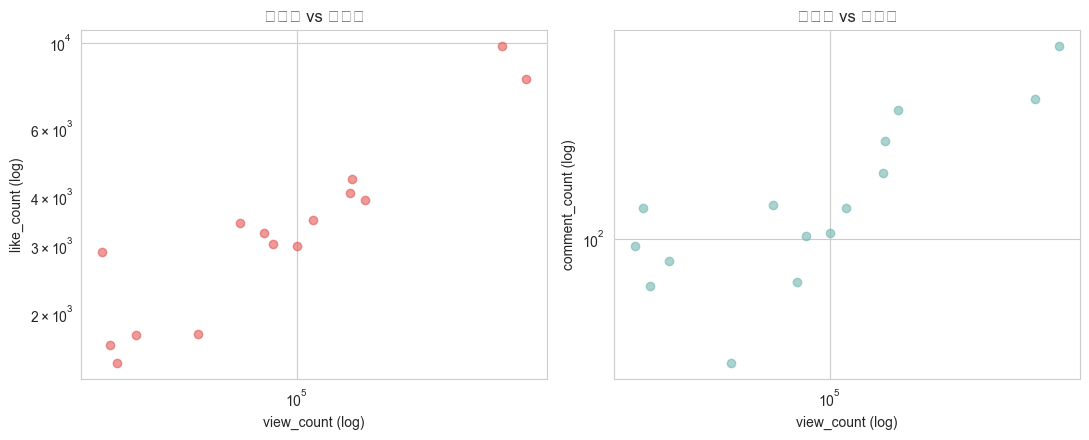

In [23]:
if len(shorts) == 0:
    print("略過")
else:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].scatter(shorts["view_count"].clip(lower=1), shorts["like_count"].clip(lower=1),
                    alpha=0.6, color="#E45756")
    axes[0].set_xscale("log"); axes[0].set_yscale("log")
    axes[0].set_xlabel("view_count (log)"); axes[0].set_ylabel("like_count (log)")
    axes[0].set_title("觀看數 vs 按讚數")

    axes[1].scatter(shorts["view_count"].clip(lower=1), shorts["comment_count"].clip(lower=1),
                    alpha=0.6, color="#72B7B2")
    axes[1].set_xscale("log"); axes[1].set_yscale("log")
    axes[1].set_xlabel("view_count (log)"); axes[1].set_ylabel("comment_count (log)")
    axes[1].set_title("觀看數 vs 留言數")
    plt.tight_layout()
    plt.show()

## 5. 互動指標衍生

把按讚／留言除以觀看數，得到每支影片的互動率。觀看數為 0 的列以 NaN 排除。

In [24]:
if len(shorts) == 0:
    print("略過")
else:
    safe_views = shorts["view_count"].where(shorts["view_count"] > 0)
    shorts["like_rate"] = shorts["like_count"] / safe_views
    shorts["comment_rate"] = shorts["comment_count"] / safe_views
    shorts["engagement_rate"] = (shorts["like_count"] + shorts["comment_count"]) / safe_views

    rates = shorts[["like_rate", "comment_rate", "engagement_rate"]].describe().T[
        ["mean", "50%", "std", "min", "max"]
    ].rename(columns={"50%": "median"})
    print(rates.round(5).to_string())

                    mean   median      std      min      max
like_rate        0.03914  0.03217  0.01727  0.02035  0.09287
comment_rate     0.00165  0.00124  0.00089  0.00065  0.00397
engagement_rate  0.04079  0.03348  0.01788  0.02156  0.09590


## 6. 簡單迴歸

以 `log10(view_count + 1)` 為應變數，自變數為時長與發布距今小時數。亦可加入 `comment_count`，但留言數與觀看數內生性高（多重共線性疑慮），結果僅供參考。

In [25]:
MIN_N = 20
if len(shorts) < MIN_N:
    print(f"Shorts 樣本數 = {len(shorts)} < {MIN_N}，迴歸結果不穩定。建議擴大抓取或放寬時長閾值。")

if len(shorts) >= 3:
    now_utc = pd.Timestamp.utcnow().tz_convert("UTC") if pd.Timestamp.utcnow().tzinfo else pd.Timestamp.now(tz="UTC")
    reg = shorts.copy()
    reg["published_hours_ago"] = (now_utc - reg["published_at"]).dt.total_seconds() / 3600.0
    reg["log_views"] = np.log10(reg["view_count"].clip(lower=0) + 1)

    X = reg[["duration_sec", "published_hours_ago"]].astype(float)
    X = sm.add_constant(X)
    y = reg["log_views"].astype(float)
    model = sm.OLS(y, X, missing="drop").fit()
    print(model.summary())
else:
    print("樣本不足，跳過迴歸")

Shorts 樣本數 = 15 < 20，迴歸結果不穩定。建議擴大抓取或放寬時長閾值。
                            OLS Regression Results                            
Dep. Variable:              log_views   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.227
Method:                 Least Squares   F-statistic:                     3.058
Date:                Sun, 10 May 2026   Prob (F-statistic):             0.0845
Time:                        22:41:55   Log-Likelihood:                -1.7400
No. Observations:                  15   AIC:                             9.480
Df Residuals:                      12   BIC:                             11.60
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

/var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/ipykernel_28059/3862192204.py:6: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  now_utc = pd.Timestamp.utcnow().tz_convert("UTC") if pd.Timestamp.utcnow().tzinfo else pd.Timestamp.now(tz="UTC")


In [26]:
# 加入 comment_count 的擴充模型（注意內生性）
if len(shorts) >= 3:
    X2 = reg[["duration_sec", "published_hours_ago", "comment_count"]].astype(float)
    X2 = sm.add_constant(X2)
    model2 = sm.OLS(y, X2, missing="drop").fit()
    print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:              log_views   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.685
Method:                 Least Squares   F-statistic:                     11.15
Date:                Sun, 10 May 2026   Prob (F-statistic):            0.00116
Time:                        22:41:55   Log-Likelihood:                 5.6447
No. Observations:                  15   AIC:                            -3.289
Df Residuals:                      11   BIC:                           -0.4571
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   4.3365    

### 係數解讀（中文）

- `duration_sec`：係數方向反映「在 0–60 秒範圍內，每多 1 秒對 log10(觀看數) 的邊際影響」；統計上是否顯著看 p-value（< 0.05 視為顯著）。
- `published_hours_ago`：通常為正——影片越早發布、累積觀看時間越長，觀看數越多；若不顯著代表近兩週的累積差距還拉不開。
- `comment_count`（擴充模型）：因為留言本身是互動結果，與觀看數同向且高度內生，係數估計只能視為描述性關聯，不可作因果推論；若加入後 R² 暴漲、其他變數 p-value 變大，多半是共線性。
- 詮釋限制：樣本只涵蓋兩週，且沒有控制標題／主題／發布時段等內容變因，這裡的迴歸主要做為示範。

## 7. 存出篩選後的 CSV

將近兩週 Shorts 子集合另存一份。下游 `comments` goal 是以 `channel_videos_*.csv` 的最新檔為輸入；若想讓它只跑這份篩選結果，可手動把輸出檔案複製／重新命名為 `channel_videos_<更晚的時間戳>.csv` 放回 `data/processed/`。

In [27]:
if len(shorts) == 0:
    print("沒有資料可存")
else:
    out_path = storage.write_csv(shorts, "pansci_shorts_filtered")
    print(f"已輸出：{out_path}")

[write] /Users/waynliu/Documents/NTU/台大/大二下/統計一下/final project/data/processed/pansci_shorts_filtered_20260510-144155.csv (15 rows)
已輸出：/Users/waynliu/Documents/NTU/台大/大二下/統計一下/final project/data/processed/pansci_shorts_filtered_20260510-144155.csv
